# 0 · Análise Exploratória (EDA) — iFood Offer Optimization

**Escopo:** esta EDA é feita **exclusivamente sobre os dados brutos**
(`profile`, `offers`, `transactions`), **antes** do processing. Usamos apenas
agregações simples (contagens, distribuições, `groupby`); a **atribuição por janela
temporal** (ligar recebeu→viu→completou dentro da validade) é *processing* e está no
notebook `1_data_processing.ipynb`.

Estrutura: Overview (período, missings, tipos, cardinalidades, metadados, target) →
exploração variável a variável (volumetria × taxa × valor × estabilidade temporal) →
correlações → conclusões que orientam as próximas etapas.

Como o desfecho definitivo por oferta só é construído no processing (depende da
janela temporal), para a EDA usamos um **alvo exploratório em nível de cliente**:
*"o cliente completou ao menos uma oferta?"* — suficiente para entender o poder
discriminante das variáveis brutas.


## Importando bibliotecas

In [59]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110
IFOOD_RED = '#EA1D2C'
from src.config import OFFERS_JSON, PROFILE_JSON, TRANSACTIONS_JSON

## Funções úteis
`plot_bad_cbk` mostra, por categoria: **quantidade** (barras) e **taxa do evento**
(linha), além de **valor financeiro** e **taxa ponderada por valor**.
`quantiliza_com_missing` faz binning por quantis tratando missing.
`plot_stacked_bar` avalia estabilidade temporal.

In [60]:
def quantiliza_com_missing(df, var, var_nova, quantil):
    """Binning por quantis; valores nulos vão para o bucket -1."""
    df1 = df.loc[~df[var].isnull()].copy()
    df2 = df.loc[df[var].isnull()].copy()
    disc = KBinsDiscretizer(n_bins=quantil, encode='ordinal', strategy='quantile', subsample=None)
    df1[var_nova] = disc.fit_transform(df1[[var]]).astype(int)
    df2[var_nova] = -1
    return pd.concat([df1, df2], axis=0).reset_index(drop=True)


def plot_bad_cbk(dataframe, var, resposta, tpv, ascending=0, x_size=13, y_size=4,
                 piso=0, teto=1.0):
    """Volumetria + taxa do evento e valor + taxa ponderada por valor, por categoria.
    resposta = alvo binário; tpv = valor financeiro."""
    d = dataframe[[var, resposta, tpv]].copy()
    d['valor_evento'] = np.where(d[resposta] == 1, d[tpv], 0.0)
    d[var] = d[var].fillna('Missing')
    g = d.groupby(var).agg(qtd=(resposta, 'size'), eventos=(resposta, 'sum'),
                           valor_evento=('valor_evento', 'sum'), valor=(tpv, 'sum')).reset_index()
    g['taxa'] = g['eventos'] / g['qtd']
    g['taxa_valor'] = g['valor_evento'] / g['valor'].replace(0, np.nan)
    g[var] = g[var].astype(str)
    if ascending == 1:
        g = g.sort_values('taxa')
    print(f'[{var}] amplitude da taxa: {g.taxa.max()-g.taxa.min():.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(x_size, y_size))
    for ax, (bar_col, line_col, ttl) in zip(
            axes, [('qtd', 'taxa', 'Qtd e taxa do evento'),
                   ('valor', 'taxa_valor', 'Valor e taxa ponderada por valor')]):
        ax.bar(g[var], g[bar_col], color='#4C72B0', alpha=.85, width=.7)
        ax.set_yticks([]); ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.set_title(f'{ttl} · "{var}"', fontsize=10)
        ax2 = ax.twinx()
        ax2.plot(g[var], g[line_col], color=IFOOD_RED, marker='o', ms=3)
        ax2.set_ylim([piso, teto])
        for x, y in zip(g[var], g[line_col]):
            if pd.notna(y): ax2.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout(); plt.show()
    return g


def plot_stacked_bar(df, variable, target_variable, normalize=True):
    """Barras empilhadas (normalizado) do target por categoria — estabilidade/mix."""
    ct = pd.crosstab(df[variable], df[target_variable])
    if normalize:
        ct = ct.div(ct.sum(axis=1), axis=0)
    ax = ct.plot(kind='bar', stacked=True, figsize=(13, 3.6), colormap='viridis')
    ax.set_title(f'"{target_variable}" por "{variable}"' + (' (normalizado)' if normalize else ''))
    ax.set_ylabel('Proporção' if normalize else 'Qtd'); ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=4); plt.tight_layout(); plt.show()


def print_correlation_matrix(df, cols, corr_max=0.75):
    """Heatmap de correlação + lista de variáveis com |corr| alta."""
    corr = df[cols].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high = [col for col in upper.columns if any(upper[col] >= corr_max)]
    f, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 20, as_cmap=True),
                center=0, annot=True, fmt='.2f', square=True, linewidths=.5,
                annot_kws={'size': 7}, cbar_kws={'shrink': .6})
    plt.title('Matriz de correlação'); plt.tight_layout(); plt.show()
    print('Variáveis com |correlação| >=', corr_max, ':', high)
    return high

## Importando dados (brutos)
`registered_on` vem como inteiro `YYYYMMDD` (ANOMESDIA) no JSON. É uma **data**, não
um número — convertemos para `datetime` já na carga para não tratá-la como numérica
(evita estatísticas sem sentido no `describe`/correlação).

In [61]:
profile = pd.read_json(PROFILE_JSON)
offers = pd.read_json(OFFERS_JSON)
tx = pd.read_json(TRANSACTIONS_JSON)

# registered_on: ANOMESDIA (YYYYMMDD) -> data
profile['registered_on'] = pd.to_datetime(profile['registered_on'], format='%Y%m%d')
print('profile', profile.shape, '| offers', offers.shape, '| transactions', tx.shape)
print('registered_on dtype:', profile.registered_on.dtype,
      '| de', profile.registered_on.min().date(), 'a', profile.registered_on.max().date())

profile (17000, 5) | offers (10, 6) | transactions (306534, 4)
registered_on dtype: datetime64[us] | de 2013-07-29 a 2018-07-26


# Overview — Perfil dos clientes
Shape, tipos, missings, cardinalidades, metadados e distribuições.

In [62]:
print('shape:', profile.shape)
profile.head()

shape: (17000, 5)


,age,registered_on,gender,id,credit_card_limit
0,118,2017-02-12,NaN,68be06ca386d4c31939f3a4f0e3dd783,NaN
1,55,2017-07-15,F,0610b486422d4921ae7d2bf64640c50b,112000.0
2,118,2018-07-12,NaN,38fe809add3b4fcf9315a9694bb96ff5,NaN
3,75,2017-05-09,F,78afa995795e4d85b5d9ceeca43f5fef,100000.0
4,118,2017-08-04,NaN,a03223e636434f42ac4c3df47e8bac43,NaN


In [63]:
# registered_on já é datetime -> describe mostra estatísticas de data, não numéricas
profile.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
age,17000.0,NaN,NaN,NaN,62.531412,18.0,45.0,58.0,73.0,118.0,26.73858
registered_on,17000,NaN,NaN,NaN,2017-02-23 13:12:10.164706,2013-07-29 00:00:00,2016-05-26 00:00:00,2017-08-02 00:00:00,2017-12-30 00:00:00,2018-07-26 00:00:00,NaN
gender,14825,3,M,8484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,17000,17000,68be06ca386d4c31939f3a4f0e3dd783,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_card_limit,14825.0,NaN,NaN,NaN,65404.991568,30000.0,49000.0,64000.0,80000.0,120000.0,21598.29941


### Análise de missings

In [64]:
miss = (profile.isna().mean()*100).round(2).sort_values(ascending=False)
print(miss)
print('\n-> gender e credit_card_limit têm ~12.8% de nulos.')

gender               12.79
credit_card_limit    12.79
age                   0.00
registered_on         0.00
id                    0.00
dtype: float64

-> gender e credit_card_limit têm ~12.8% de nulos.


### Tipos, cardinalidades e metadados (tabela consolidada)

In [65]:
meta = pd.DataFrame({'dtype': profile.dtypes.astype(str),
                     'cardinalidade': profile.nunique(),
                     'missing_%': (profile.isna().mean()*100).round(2)})
meta

,dtype,cardinalidade,missing_%
age,int64,85,0.00
registered_on,datetime64[us],1716,0.00
gender,str,3,12.79
id,str,17000,0.00
credit_card_limit,float64,91,12.79


### O placeholder de idade (`age == 118`)

In [66]:
print('clientes com age==118:', (profile.age==118).sum())
print('desses, gender nulo :', profile.loc[profile.age==118,'gender'].isna().mean())
print('desses, limite nulo :', profile.loc[profile.age==118,'credit_card_limit'].isna().mean())
print('-> 118 é placeholder de perfil incompleto (100% coincide com os nulos).')

clientes com age==118: 2175
desses, gender nulo : 1.0
desses, limite nulo : 1.0
-> 118 é placeholder de perfil incompleto (100% coincide com os nulos).


### O placeholder tem concentração de data de cadastro?
Pergunta: o `age==118` é um **lote específico** (ex.: uma migração de dados legada
num único dia) ou está espalhado pelo tempo, proporcional ao crescimento normal da
base? Comparamos a cadência mensal de cadastro dos dois grupos.

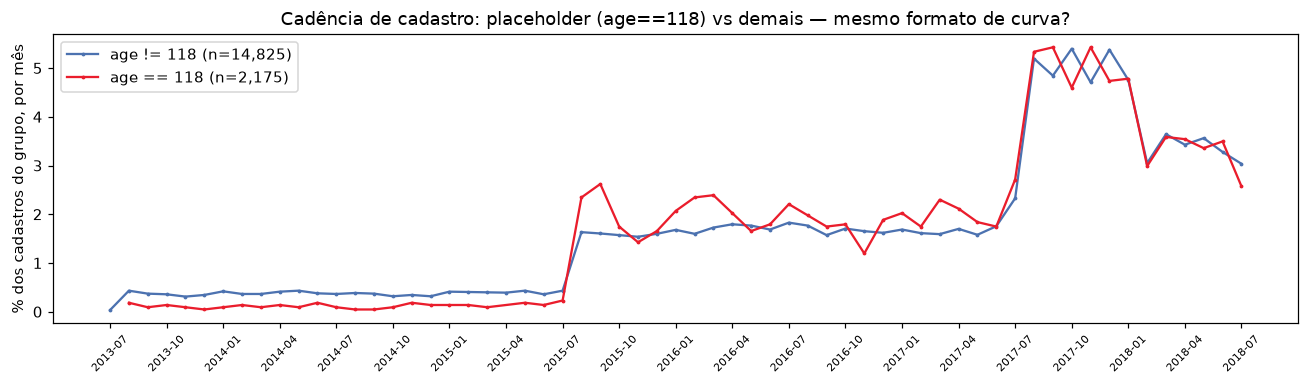

maior concentração num único dia — placeholder: 11 (0.5% do grupo) | demais: 39 (0.3% do grupo)
dias distintos de cadastro — placeholder: 950 de 2175 | demais: 1707 de 14825

distribuição por ano (% dentro de cada grupo):
age            age!=118  age==118
registered_on                    
2013              0.018     0.006
2014              0.045     0.013
2015              0.108     0.107
2016              0.204     0.231
2017              0.378     0.400
2018              0.247     0.243


In [67]:
p_ph = profile[profile.age == 118]
p_ok = profile[profile.age != 118]

m_ph = p_ph.registered_on.dt.to_period('M').value_counts(normalize=True).sort_index()
m_ok = p_ok.registered_on.dt.to_period('M').value_counts(normalize=True).sort_index()
m_ph.index = m_ph.index.astype(str); m_ok.index = m_ok.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(m_ok.index, m_ok.values*100, color='#4C72B0', marker='.', ms=3, label=f'age != 118 (n={len(p_ok):,})')
ax.plot(m_ph.index, m_ph.values*100, color=IFOOD_RED, marker='.', ms=3, label=f'age == 118 (n={len(p_ph):,})')
ax.set_xticks(ax.get_xticks()[::3]); ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.set_ylabel('% dos cadastros do grupo, por mês')
ax.set_title('Cadência de cadastro: placeholder (age==118) vs demais — mesmo formato de curva?')
ax.legend(); plt.tight_layout(); plt.show()

max_day_ph = p_ph.registered_on.dt.date.value_counts().max()
max_day_ok = p_ok.registered_on.dt.date.value_counts().max()
print(f'maior concentração num único dia — placeholder: {max_day_ph} ({max_day_ph/len(p_ph):.1%} do grupo) '
      f'| demais: {max_day_ok} ({max_day_ok/len(p_ok):.1%} do grupo)')
print(f'dias distintos de cadastro — placeholder: {p_ph.registered_on.dt.date.nunique()} de {len(p_ph)} '
      f'| demais: {p_ok.registered_on.dt.date.nunique()} de {len(p_ok)}')

print('\ndistribuição por ano (% dentro de cada grupo):')
print(pd.crosstab(profile.registered_on.dt.year, profile.age == 118, normalize='columns')
      .rename(columns={False: 'age!=118', True: 'age==118'}).round(3).to_string())

**Leitura:** **não há concentração temporal.** As duas curvas mensais praticamente
se sobrepõem, e a distribuição por ano é quase idêntica entre os grupos (ex.: 2017
concentra 40,0% do grupo placeholder vs 37,8% dos demais; 2016: 23,1% vs 20,4%). O
dia de maior volume dentro do grupo placeholder representa só ~0,5% dele — muito
longe de indicar um lote/importação pontual.

Isso **descarta a hipótese de migração/evento único** como origem do placeholder.
O padrão sugere, em vez disso, uma **falha estrutural persistente** no fluxo de
cadastro — uma fração constante de usuários (~12,8%) não preenche idade/gênero/
limite, e isso se repete de forma proporcional ao longo de toda a janela de dados
(2013–2018), não em um pico isolado.

### Distribuições — idade, gênero, limite de crédito, ano de cadastro
Dados **brutos, sem pré-filtro**: se há placeholder ou nulo, o gráfico deve
deixar isso visível (não escondemos nada antes de plotar).

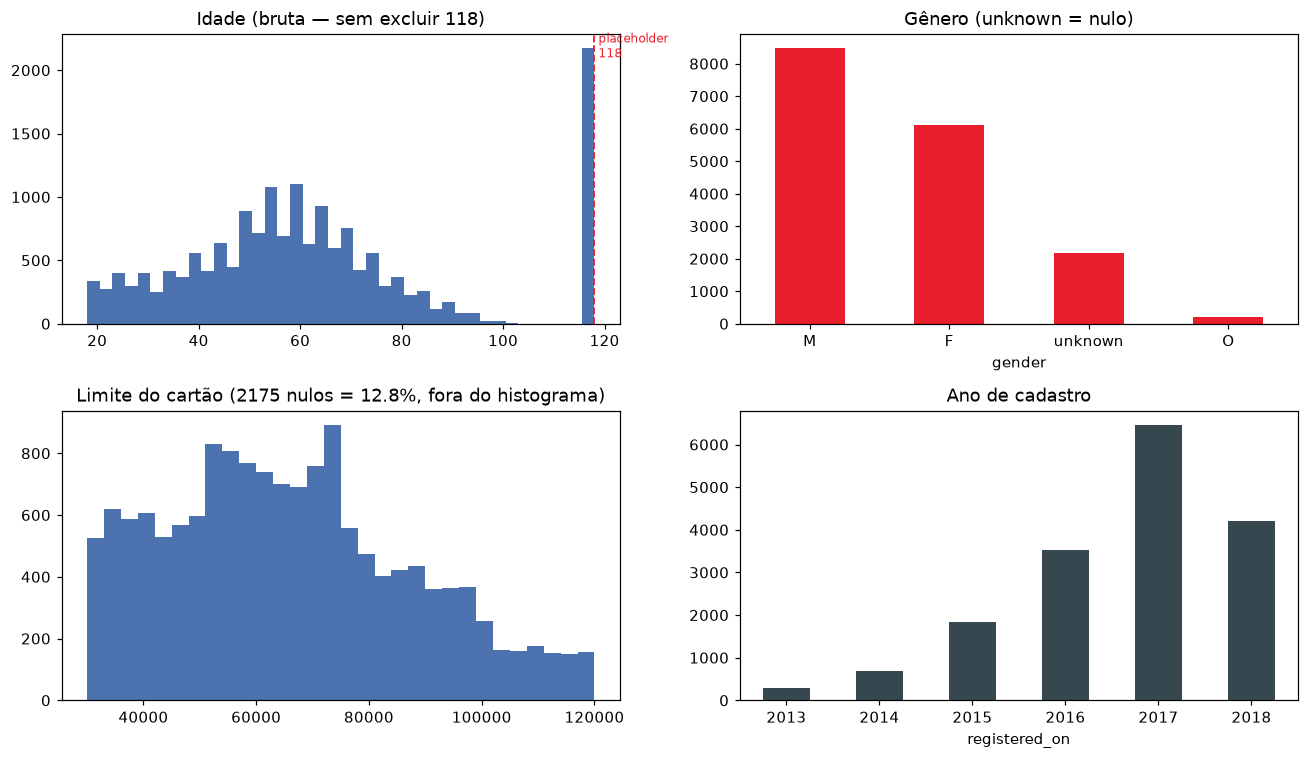

In [68]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))

# idade SEM filtrar o placeholder — o pico em 118 tem que aparecer no histograma
ax[0,0].hist(profile.age, bins=40, color='#4C72B0')
ax[0,0].axvline(118, color=IFOOD_RED, ls='--', lw=1.2)
ax[0,0].text(118, ax[0,0].get_ylim()[1]*0.92, ' placeholder\n 118', color=IFOOD_RED, fontsize=8)
ax[0,0].set_title('Idade (bruta — sem excluir 118)')

# gênero: nulo vira sua própria barra ('unknown'), não desaparece
profile.gender.fillna('unknown').value_counts().plot.bar(ax=ax[0,1], color=IFOOD_RED)
ax[0,1].set_title('Gênero (unknown = nulo)'); ax[0,1].tick_params(rotation=0)

# limite: histograma só aceita número (NaN não entra), mas o nº de nulos fica anotado no título
n_null_lim = profile.credit_card_limit.isna().sum()
ax[1,0].hist(profile.credit_card_limit.dropna(), bins=30, color='#4C72B0')
ax[1,0].set_title(f'Limite do cartão ({n_null_lim} nulos = {n_null_lim/len(profile):.1%}, fora do histograma)')

if not pd.api.types.is_datetime64_any_dtype(profile['registered_on']):
    profile['registered_on'] = pd.to_datetime(profile['registered_on'], format='%Y%m%d')
profile.registered_on.dt.year.value_counts().sort_index().plot.bar(ax=ax[1,1], color='#37474F')
ax[1,1].set_title('Ano de cadastro'); ax[1,1].tick_params(rotation=0)
plt.tight_layout(); plt.show()

**Leitura:** o histograma de idade expõe o próprio problema — um pico
isolado em **118**, destacado no gráfico, claramente fora da distribuição normal
que vai até ~100. Gênero mostra a barra `unknown` (nulo) do tamanho real (12,8%).
Limite de crédito: o histograma matemático não plota `NaN`, então o título
declara quantos ficaram de fora — os mesmos 12,8% do gênero. As três pistas
juntas (idade 118 + gênero nulo + limite nulo) confirmam que é o mesmo grupo de
perfis incompletos.

### Idade por gênero
Densidades sobrepostas para comparar o **formato** das distribuições (não só a
média). O grupo `unknown` não entra aqui por construção: gênero nulo ≡ `age==118`,
ou seja, esse grupo não tem **nem** gênero **nem** idade válida para plotar.

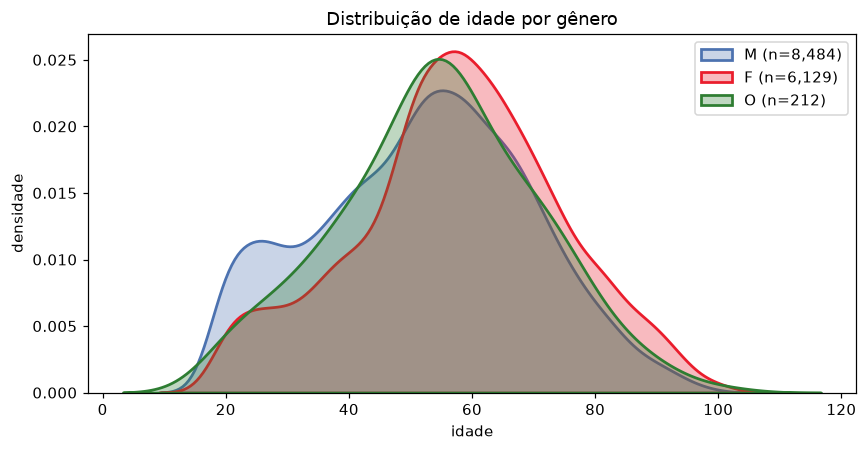

        count  mean  median   std
gender                           
F        6129  57.5    58.0  16.9
M        8484  52.1    53.0  17.4
O         212  54.4    55.0  16.2

% dentro de cada gênero por faixa etária:
age     18-30  31-45  46-60  61-75   75+
gender                                  
F         7.8   14.2   34.6   29.1  14.2
M        14.3   20.5   32.1   24.3   8.9
O         8.5   18.4   40.6   22.6   9.9


In [69]:
age_ok = profile[profile.age != 118]
cores = {'M': '#4C72B0', 'F': IFOOD_RED, 'O': '#2E7D32'}

fig, ax = plt.subplots(figsize=(8, 4.2))
for g in ['M', 'F', 'O']:
    s = age_ok.loc[age_ok.gender == g, 'age']
    sns.kdeplot(s, ax=ax, fill=True, alpha=.30, lw=1.8,
                color=cores[g], label=f'{g} (n={len(s):,})')
ax.set_xlabel('idade'); ax.set_ylabel('densidade')
ax.set_title('Distribuição de idade por gênero')
ax.legend()
plt.tight_layout(); plt.show()

print(age_ok.groupby('gender').age.agg(['count','mean','median','std']).round(1).to_string())
print('\n% dentro de cada gênero por faixa etária:')
faixa = pd.cut(age_ok.age, [17,30,45,60,75,110], labels=['18-30','31-45','46-60','61-75','75+'])
print((pd.crosstab(age_ok.gender, faixa, normalize='index')*100).round(1).to_string())

**Leitura:** as duas curvas principais têm o **mesmo pico** (~55–58 anos), mas
formatos diferentes na cauda jovem: os homens têm um **ombro visível entre 20 e 40
anos** que praticamente não existe nas mulheres — 14,3% dos homens estão na faixa
18–30, contra 7,8% das mulheres. O efeito líquido é uma diferença de **~5 anos na
média** (F 57,5 vs M 52,1) e de 5 anos na mediana (58 vs 53). O grupo `O` (n=212)
fica entre os dois, mas com amostra pequena demais para leitura conclusiva.

Isso conversa com o achado de limite de crédito: as mulheres da base são **mais
velhas e com limite maior** — consistente com renda acumulada ao longo da vida, e
não com dois efeitos independentes.

### Idade da conta (`account_age`)
Feature de perfil = **há quanto tempo o cliente tem conta** (tempo desde
`registered_on`). Como a data absoluta do teste não é dada, usamos como referência o
**cadastro mais recente da base** (proxy do início do teste, t=0). Criamos
`account_age_days` e `account_age_years`.

data de referência (t=0): 2018-07-26
count    17000.00
mean         1.42
std          1.13
min          0.00
5%           0.12
25%          0.57
50%          0.98
75%          2.17
95%          3.77
max          4.99


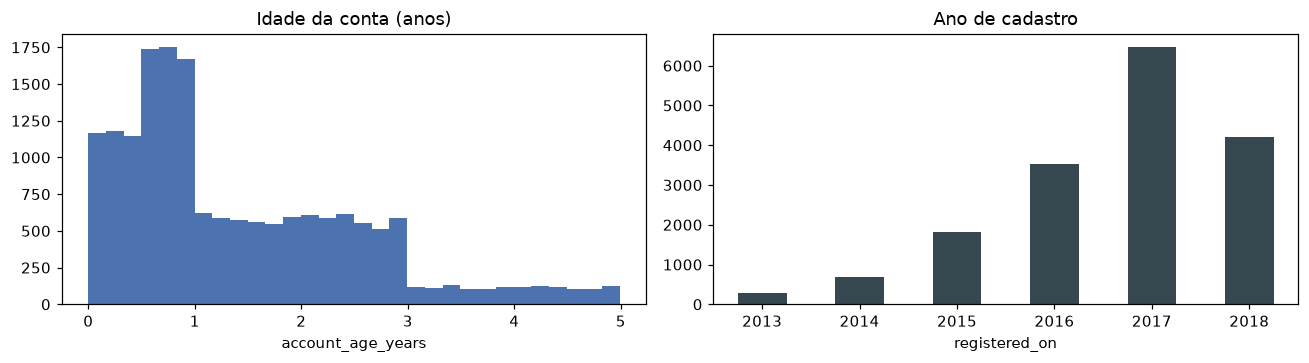

In [70]:
# robusto à ordem de execução: garante registered_on como datetime
if not pd.api.types.is_datetime64_any_dtype(profile['registered_on']):
    profile['registered_on'] = pd.to_datetime(profile['registered_on'], format='%Y%m%d')
ref_date = profile.registered_on.max()   # proxy de 'hoje' / t=0 do teste
profile['account_age_days'] = (ref_date - profile.registered_on).dt.days
profile['account_age_years'] = (profile['account_age_days'] / 365.25).round(2)
print('data de referência (t=0):', ref_date.date())
print(profile['account_age_years'].describe(percentiles=[.05,.25,.5,.75,.95]).round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(profile.account_age_years, bins=30, color='#4C72B0')
ax[0].set_title('Idade da conta (anos)'); ax[0].set_xlabel('account_age_years')
profile.registered_on.dt.year.value_counts().sort_index().plot.bar(ax=ax[1], color='#37474F')
ax[1].set_title('Ano de cadastro'); ax[1].tick_params(rotation=0)
plt.tight_layout(); plt.show()

**Leitura:** a idade da conta vai de ~0 a ~5 anos (cadastros de 2013 a 2018),
concentrada em contas **novas (0–1 ano)** — reflexo do pico de aquisição em 2017–2018.
Poucas contas antigas (2013–2015). É um sinal de **maturidade/relacionamento** do
cliente, complementar à idade da pessoa.

## Perfil socioeconômico do público
O `credit_card_limit` é o melhor marcador de estrato social disponível. Analisamos
sua distribuição, os cortes por faixa e — em destaque — a **combinação gênero ×
limite**.

In [71]:
# Boxplot/KDE por gênero (abaixo) não plotam NaN — esse filtro é uma
# necessidade matemática do gráfico, não uma limpeza escondida. Por isso
# imprimimos exatamente quem fica de fora, E por gênero, antes de seguir —
# para provar que 'O' (other) não é afetado (age==118 não tem esse gênero).
n_excl = (profile.age == 118).sum()
print(f'excluídos desta seção: {n_excl} clientes ({n_excl/len(profile):.1%}) '
      f'— mesmo grupo de age==118 / limite nulo / gênero nulo já visto acima')
print('\ncomposição de gênero ANTES do filtro:')
print(profile.gender.fillna('unknown').value_counts().to_string())
pv = profile[profile.age != 118].copy()
print('\ncomposição de gênero DEPOIS do filtro (deve preservar F/M/O intactos):')
print(pv.gender.value_counts().to_string())
print('limite — describe (apenas quem tem limite conhecido):')
print(pv.credit_card_limit.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(0).to_string())
bins=[0,30000,50000,80000,100000,120000,1e9]
labels=['<30k','30-50k','50-80k','80-100k','100-120k','>120k']
pv['faixa_limite']=pd.cut(pv.credit_card_limit,bins,labels=labels)
print('\ndistribuição por faixa de limite:')
print(pv.faixa_limite.value_counts().sort_index().to_string())
print('\n-> piso rígido em 30k e teto em 120k: sem baixa renda e sem elite (base curada/sintética).')

excluídos desta seção: 2175 clientes (12.8%) — mesmo grupo de age==118 / limite nulo / gênero nulo já visto acima

composição de gênero ANTES do filtro:
gender
M          8484
F          6129
unknown    2175
O           212

composição de gênero DEPOIS do filtro (deve preservar F/M/O intactos):
gender
M    8484
F    6129
O     212
limite — describe (apenas quem tem limite conhecido):
count     14825.0
mean      65405.0
std       21598.0
min       30000.0
1%        31000.0
5%        34000.0
25%       49000.0
50%       64000.0
75%       80000.0
95%      105000.0
99%      117000.0
max      120000.0

distribuição por faixa de limite:
faixa_limite
<30k          88
30-50k      3946
50-80k      7226
80-100k     2559
100-120k    1006
>120k          0

-> piso rígido em 30k e teto em 120k: sem baixa renda e sem elite (base curada/sintética).


### Gênero × Limite de crédito (destaque)
`unknown` não aparece nos gráficos (a) e (b) por uma razão estrutural, não por
filtro escondido: é o mesmo grupo do placeholder `age==118`, e **100% desse
grupo também tem `credit_card_limit` nulo** — não existe valor numérico para
desenhar num boxplot ou numa densidade. O gráfico (c) inclui `unknown` de
propósito: ali ele aparece como **100% "sem dado"**, o que é informativo.

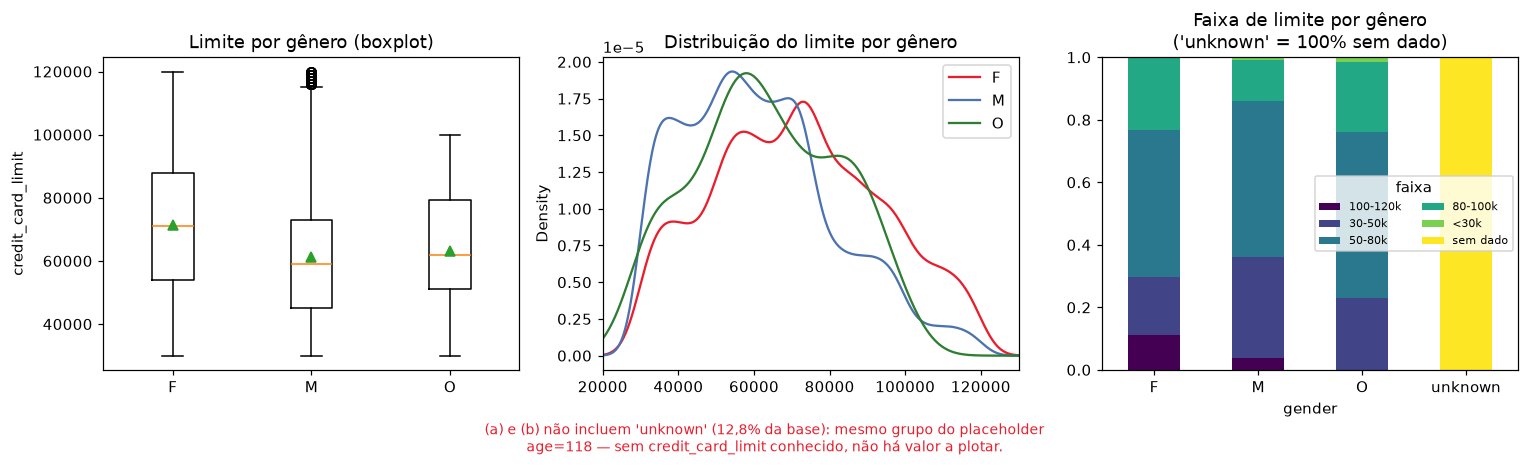

mediana de limite por gênero (unknown fica de fora — não tem limite):
         median     mean  count
gender                         
F       71000.0  71306.0   6129
M       59000.0  61195.0   8484
O       62000.0  63288.0    212


In [72]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
order = ['F','M','O']

# (a) boxplot do limite por gênero — 'unknown' fica fora: seu limite é 100% nulo
data = [pv.loc[pv.gender==g,'credit_card_limit'].dropna() for g in order]
ax[0].boxplot(data, tick_labels=order, showmeans=True)
ax[0].set_title('Limite por gênero (boxplot)'); ax[0].set_ylabel('credit_card_limit')

# (b) densidade do limite por gênero — mesma razão
for g,c in zip(order, [IFOOD_RED,'#4C72B0','#2E7D32']):
    pv.loc[pv.gender==g,'credit_card_limit'].plot.kde(ax=ax[1], label=g, color=c)
ax[1].set_title('Distribuição do limite por gênero'); ax[1].set_xlim(20000,130000); ax[1].legend()

# (c) mix de faixas de limite — aqui SIM incluímos 'unknown', usando a base
# bruta (profile, não pv) e tratando limite nulo como sua própria categoria
prof_mix = profile.copy()
prof_mix['gender'] = prof_mix['gender'].fillna('unknown')
prof_mix['faixa_limite'] = pd.cut(prof_mix.credit_card_limit, bins, labels=labels)
prof_mix['faixa_limite'] = prof_mix['faixa_limite'].astype('object').fillna('sem dado')
order_c = order + ['unknown']
mix = pd.crosstab(prof_mix.gender, prof_mix.faixa_limite, normalize='index').loc[order_c]
mix.plot(kind='bar', stacked=True, ax=ax[2], colormap='viridis')
ax[2].set_title("Faixa de limite por gênero\n('unknown' = 100% sem dado)")
ax[2].tick_params(axis='x', rotation=0)
ax[2].legend(fontsize=7, ncol=2, title='faixa')

fig.text(0.5, -0.04,
         "(a) e (b) não incluem 'unknown' (12,8% da base): mesmo grupo do placeholder\n"
         "age=118 — sem credit_card_limit conhecido, não há valor a plotar.",
         ha='center', fontsize=9, color=IFOOD_RED)
plt.tight_layout(); plt.show()

print('mediana de limite por gênero (unknown fica de fora — não tem limite):')
print(pv.groupby('gender').credit_card_limit.agg(['median','mean','count']).round(0).to_string())

### Gênero × Limite × Idade (mediana de limite)

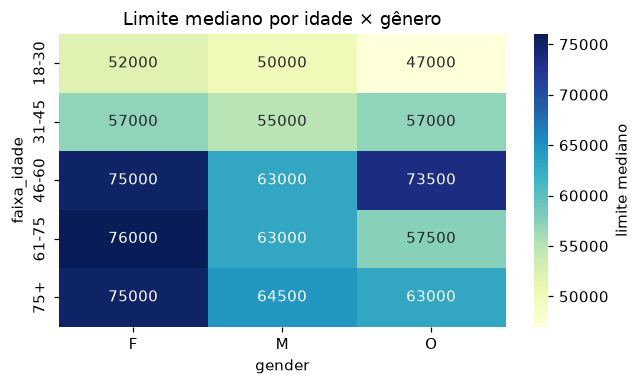

In [73]:
pv['faixa_idade']=pd.cut(pv.age,[17,30,45,60,75,110],labels=['18-30','31-45','46-60','61-75','75+'])
heat = pv.pivot_table(index='faixa_idade', columns='gender', values='credit_card_limit', aggfunc='median')
fig, ax = plt.subplots(figsize=(6,3.6))
sns.heatmap(heat[order], annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label':'limite mediano'})
ax.set_title('Limite mediano por idade × gênero'); plt.tight_layout(); plt.show()

### Composição geracional (quem é o público)
Descritivo — traduz a idade em gerações (nascimento ≈ 2018 − idade, dado que o teste
ocorre por volta de 2018).

geracao
Boomer+ (≤1964)         54.3
Gen X (1965-80)         27.2
Millennial (1981-96)    15.3
Gen Z (1997+)            3.2


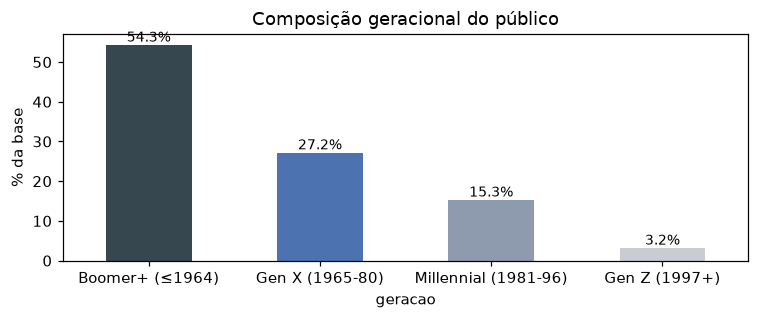

In [74]:
pv['nasc'] = 2018 - pv['age']
def geracao(y):
    if y <= 1964: return 'Boomer+ (≤1964)'
    if y <= 1980: return 'Gen X (1965-80)'
    if y <= 1996: return 'Millennial (1981-96)'
    return 'Gen Z (1997+)'
order_ger = ['Boomer+ (≤1964)','Gen X (1965-80)','Millennial (1981-96)','Gen Z (1997+)']
pv['geracao'] = pd.Categorical(pv['nasc'].apply(geracao), categories=order_ger, ordered=True)
comp = (pv.geracao.value_counts(normalize=True).reindex(order_ger)*100).round(1)
print(comp.to_string())
fig, ax = plt.subplots(figsize=(7,3))
comp.plot.bar(ax=ax, color=['#37474F','#4C72B0','#8E9BAE','#C9CDD3'])
ax.set_ylabel('% da base'); ax.set_title('Composição geracional do público'); ax.tick_params(rotation=0)
for i,v in enumerate(comp): ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

**Leitura:** ~**81% Boomer + Gen X** — público maduro. Millennials são minoria
(~15%) e Gen Z quase inexistente (~3%). Coerente com o estrato financeiro estável
(limites mais altos, renda acumulada).

**Leitura — perfil socioeconômico:**
- **Classe média a média-alta, 100% bancarizada.** Piso rígido de R$30k (sem baixa
  renda) e teto de R$120k (sem elite): a base é o "miolo" da pirâmide, provavelmente
  **filtrada/sintética** → usar o limite como **proxy ordinal de estrato**, não valor literal.
- **Público maduro** (mediana 55 anos) e financeiramente estabelecido.
- **Gênero × limite:** as **mulheres têm limite consistentemente maior** que os homens
  (mediana ~71k vs ~59k), diferença que se mantém em quase todas as faixas etárias
  (heatmap). O grupo `O` é pequeno (~1,4%) — ler com cautela.
- **Limite cresce com a idade** em ambos os gêneros (acúmulo de renda ao longo da vida).

**Implicação para o case:** os achados valem **para este estrato**; extrapolar para
classes C/D ou não-bancarizados (público real do iFood) é arriscado — registrado como
**limitação de generalização**. Público mais velho e de renda estável também tende a
uma **compra basal alta** (característica relevante a considerar na estratégia).

# Overview — Ofertas
10 ofertas de 3 tipos. Tipo, canais, valor mínimo, desconto e duração.

In [17]:
display(offers)
print('tipos:', offers.offer_type.value_counts().to_dict())

,channels,min_value,duration,id,offer_type,discount_value
0,"[email, mobile, social]",10,7,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10
1,"[web, email, mobile, social]",10,5,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10
2,"[web, email, mobile]",0,4,3f207df678b143eea3cee63160fa8bed,informational,0
3,"[web, email, mobile]",5,7,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5
4,"[web, email]",20,10,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5
5,"[web, email, mobile, social]",7,7,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3
6,"[web, email, mobile, social]",10,10,fafdcd668e3743c1bb461111dcafc2a4,discount,2
7,"[email, mobile, social]",0,3,5a8bc65990b245e5a138643cd4eb9837,informational,0
8,"[web, email, mobile, social]",5,5,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5
9,"[web, email, mobile]",10,7,2906b810c7d4411798c6938adc9daaa5,discount,2


tipos: {'bogo': 4, 'discount': 4, 'informational': 2}


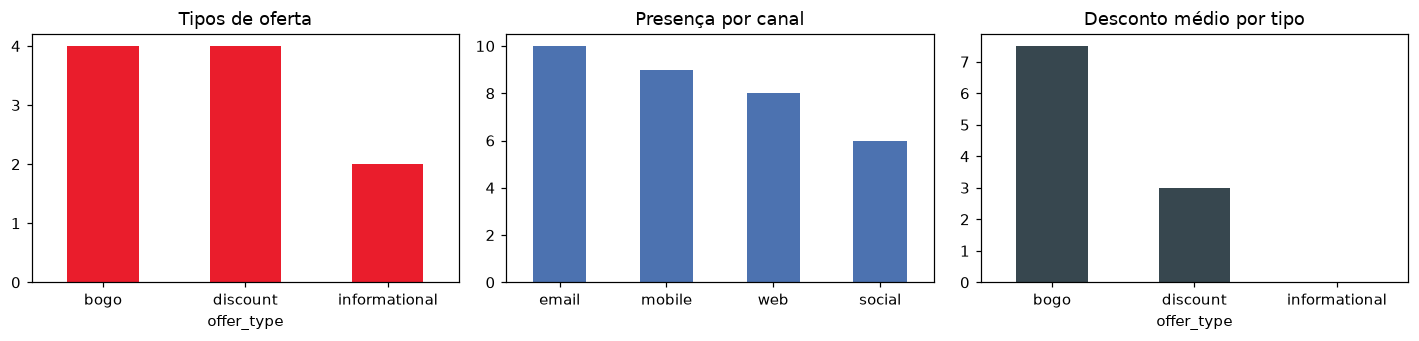

In [18]:
from itertools import chain
ch = pd.Series(list(chain.from_iterable(offers.channels)))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
offers.offer_type.value_counts().plot.bar(ax=ax[0], color=IFOOD_RED); ax[0].set_title('Tipos de oferta'); ax[0].tick_params(rotation=0)
ch.value_counts().plot.bar(ax=ax[1], color='#4C72B0'); ax[1].set_title('Presença por canal'); ax[1].tick_params(rotation=0)
offers.groupby('offer_type')['discount_value'].mean().plot.bar(ax=ax[2], color='#37474F'); ax[2].set_title('Desconto médio por tipo'); ax[2].tick_params(rotation=0)
plt.tight_layout(); plt.show()

**Leitura:** 4 BOGO, 4 discount, 2 informational; `email` está em quase todas;
`informational` não tem desconto (só divulga); duração de 3 a 10 dias — parâmetro-chave
da janela de atribuição usada no processing.

## Mecânica das ofertas e economia (custo por conclusão)
Os três campos definem as "regras" de cada oferta:
- **`min_value`** — gasto mínimo para ativar a oferta (limiar de receita);
- **`duration`** — validade em dias (define a **janela de atribuição** do processing);
- **`discount_value`** — valor do benefício = **recompensa que o iFood paga** por conclusão.

A relação entre eles muda por tipo e define a **eficiência financeira** da oferta:
`min_value / discount_value` ≈ quanto de gasto é destravado por real de recompensa.

In [19]:
mec = offers.copy()
mec['custo_recompensa'] = mec['discount_value']            # o que o iFood paga
mec['gasto_minimo'] = mec['min_value']                     # receita mínima destravada
mec['eficiencia (min/desc)'] = np.where(mec['discount_value']>0,
                                        mec['min_value']/mec['discount_value'], np.nan)
print(mec[['offer_type','min_value','discount_value','duration','eficiencia (min/desc)']]
      .sort_values('offer_type').to_string(index=False))
print('\n=== média por tipo ===')
print(mec.groupby('offer_type').agg(
        min_value=('min_value','mean'), discount_value=('discount_value','mean'),
        duration=('duration','mean'), eficiencia=('eficiencia (min/desc)','mean')).round(2).to_string())

   offer_type  min_value  discount_value  duration  eficiencia (min/desc)
         bogo         10              10         7               1.000000
         bogo         10              10         5               1.000000
         bogo          5               5         7               1.000000
         bogo          5               5         5               1.000000
     discount         20               5        10               4.000000
     discount          7               3         7               2.333333
     discount         10               2        10               5.000000
     discount         10               2         7               5.000000
informational          0               0         4                    NaN
informational          0               0         3                    NaN

=== média por tipo ===
               min_value  discount_value  duration  eficiencia
offer_type                                                    
bogo                7.50            

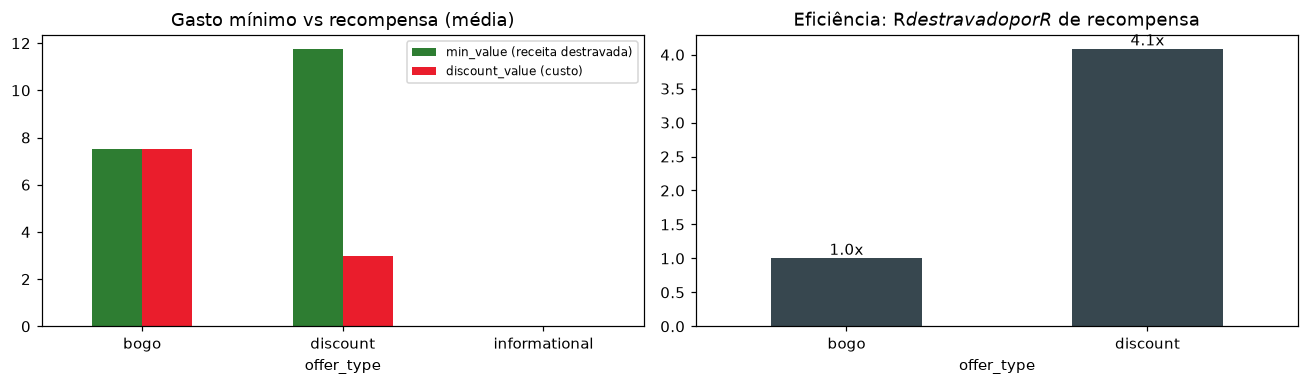

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
g = mec.groupby('offer_type')[['min_value','discount_value']].mean()
g.plot.bar(ax=ax[0], color=['#2E7D32', IFOOD_RED]); ax[0].set_title('Gasto mínimo vs recompensa (média)')
ax[0].tick_params(rotation=0); ax[0].legend(['min_value (receita destravada)','discount_value (custo)'], fontsize=8)
eff = mec.groupby('offer_type')['eficiencia (min/desc)'].mean().dropna()
eff.plot.bar(ax=ax[1], color='#37474F'); ax[1].set_title('Eficiência: R$ destravado por R$ de recompensa')
ax[1].tick_params(rotation=0)
for i,v in enumerate(eff): ax[1].text(i, v, f'{v:.1f}x', ha='center', va='bottom')
plt.tight_layout(); plt.show()

**Leitura — economia das ofertas:**
- **BOGO** paga alto: `min_value ≈ discount_value` (ex.: gaste 10, ganhe 10) →
  eficiência ~**1x** (paga R$1 de recompensa por R$1 destravado).
- **Discount** é enxuto: `min_value > discount_value` (ex.: gaste 20, ganhe 5) →
  eficiência ~**4x** — destrava muito mais gasto por real de recompensa.
- **Informational** não tem `min_value` nem `discount_value` (só divulga); por isso
  seu desfecho precisa ser medido de forma diferente (transação na janela, não
  "conclusão").

Ou seja, os tipos de oferta diferem fortemente em **custo por conclusão** — fator a
levar em conta ao comparar sua rentabilidade.

# Overview — Transações
Normalizamos o campo `value` e exploramos eventos, período e valores.

In [21]:
tx.head()

,event,account_id,value,time_since_test_start
0,offer received,78afa995795e4d85b5d9ceeca43f5fef,"{'amount': None, 'offer id': '9b98b8c7a33c4b65...",0.0
1,offer received,a03223e636434f42ac4c3df47e8bac43,"{'amount': None, 'offer id': '0b1e1539f2cc45b7...",0.0
2,offer received,e2127556f4f64592b11af22de27a7932,"{'amount': None, 'offer id': '2906b810c7d44117...",0.0
3,offer received,8ec6ce2a7e7949b1bf142def7d0e0586,"{'amount': None, 'offer id': 'fafdcd668e3743c1...",0.0
4,offer received,68617ca6246f4fbc85e91a2a49552598,"{'amount': None, 'offer id': '4d5c57ea9a6940dd...",0.0


Essa tabela contém eventos de **transações**, **ofertas recebidas**, **ofertas
visualizadas** e **ofertas completadas** — todos empilhados na mesma estrutura, com
o detalhe de cada um aninhado no campo `value`.

### Distribuição relativa dos tipos de evento

<Axes: xlabel='event'>

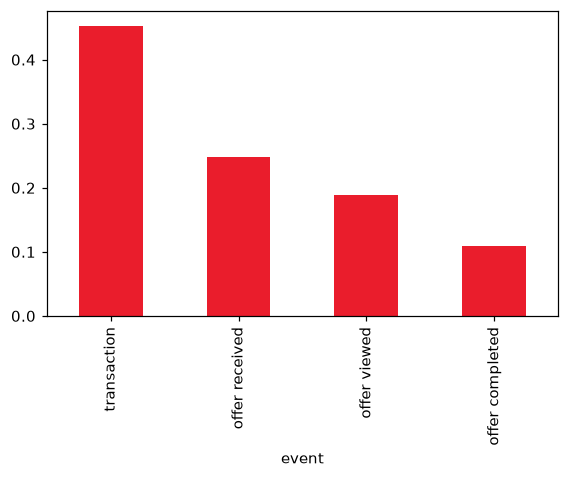

In [22]:
tx.event.value_counts(normalize=True).plot.bar(color=IFOOD_RED, figsize=(6,3.6))

### Parsing do campo `value` e cobertura temporal

In [23]:
tx['offer_id'] = tx['value'].apply(lambda d: d.get('offer id') or d.get('offer_id'))
tx['amount'] = tx['value'].apply(lambda d: d.get('amount'))
print('eventos:', tx.event.value_counts().to_dict())
print('período (dias):', tx.time_since_test_start.min(), '->', tx.time_since_test_start.max())
print('clientes distintos:', tx.account_id.nunique())

eventos: {'transaction': 138953, 'offer received': 76277, 'offer viewed': 57725, 'offer completed': 33579}
período (dias): 0.0 -> 29.75
clientes distintos: 17000


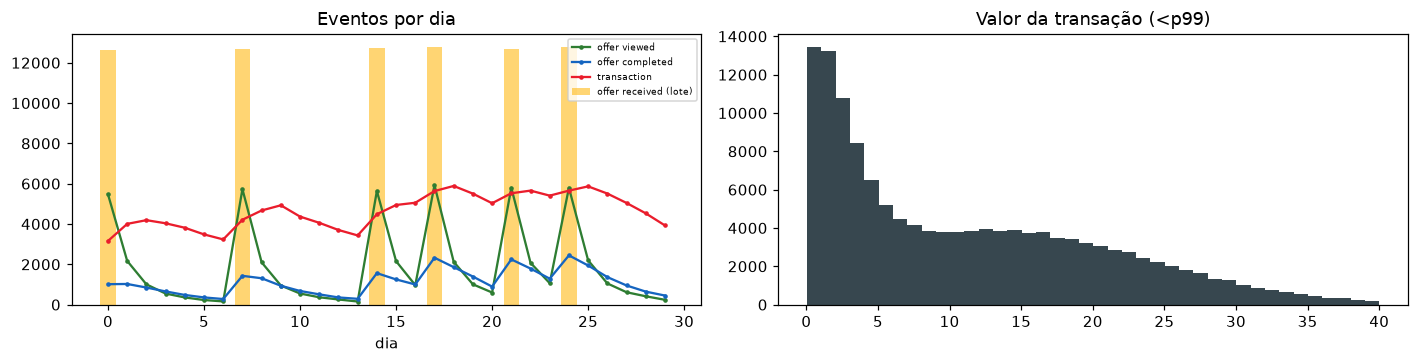

dias de envio (offer received > 0): [0, 7, 14, 17, 21, 24]
amount: média 12.78 | mediana 8.89 | max 1062.28


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))

# Eventos por dia. 'offer received' é EM LOTE (só em 6 dias) -> barras;
# viewed/completed/transaction fluem no tempo -> linhas. fillna(0) evita a
# 'linha invisível' de pontos isolados entre NaNs.
byday = tx.groupby([tx.time_since_test_start.astype(int), 'event']).size().unstack('event').fillna(0)
ax[0].bar(byday.index, byday['offer received'], color='#FFB300', alpha=.55, label='offer received (lote)')
for ev, col in [('offer viewed','#2E7D32'),('offer completed','#1565C0'),('transaction',IFOOD_RED)]:
    ax[0].plot(byday.index, byday[ev], color=col, marker='o', ms=2, label=ev)
ax[0].set_title('Eventos por dia'); ax[0].set_xlabel('dia'); ax[0].legend(fontsize=6)

amt = tx.amount.dropna()
ax[1].hist(amt[amt < amt.quantile(.99)], bins=40, color='#37474F'); ax[1].set_title('Valor da transação (<p99)')
plt.tight_layout(); plt.show()
send_days = list(byday.index[byday['offer received']>0])
print('dias de envio (offer received > 0):', send_days)
print('amount: média %.2f | mediana %.2f | max %.2f' % (amt.mean(), amt.median(), amt.max()))

**Leitura:** o **recebimento de ofertas é em lote**, concentrado em 6 dias
(**0, 7, 14, 17, 21, 24**) — não é contínuo (por isso vira barras, não linha). A
cadência **acelera** ao longo do teste: começa semanal (0→7→14) e passa a cada 3–4
dias (14→17→21→24). Cada envio dispara uma **onda decrescente** de visualizações e
conclusões nos dias seguintes. Transações ocorrem todos os dias; o valor é fortemente
assimétrico à direita (poucos tickets muito altos).

# Funil agregado de ofertas (contagem de eventos)
Sem atribuição por janela — apenas contagens brutas por tipo de evento e por oferta.

recebidas=76,277 | vistas=57,725 | completadas=33,579
taxa de visualização (agregada): 75.7%
taxa de conclusão   (agregada): 44.0%


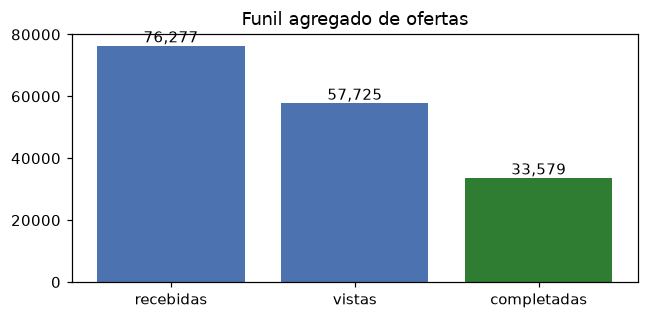

In [25]:
ev = tx.groupby('event').account_id.count()
rec, vie, com = ev['offer received'], ev['offer viewed'], ev['offer completed']
print(f'recebidas={rec:,} | vistas={vie:,} | completadas={com:,}')
print(f'taxa de visualização (agregada): {vie/rec:.1%}')
print(f'taxa de conclusão   (agregada): {com/rec:.1%}')
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(['recebidas','vistas','completadas'], [rec,vie,com], color=['#4C72B0','#4C72B0','#2E7D32'])
for i,v in enumerate([rec,vie,com]): ax.text(i, v, f'{v:,}', ha='center', va='bottom')
ax.set_title('Funil agregado de ofertas'); plt.tight_layout(); plt.show()

### Funil por tipo de oferta

In [26]:
om = offers.set_index('id')['offer_type'].to_dict()
tx['offer_type'] = tx['offer_id'].map(om)
tab = (tx[tx.event.isin(['offer received','offer viewed','offer completed'])]
       .pivot_table(index='offer_type', columns='event', values='account_id', aggfunc='count', fill_value=0))
tab['view_rate'] = tab['offer viewed']/tab['offer received']
tab['completion_rate'] = tab.get('offer completed',0)/tab['offer received']
tab.round(3)

event,offer completed,offer received,offer viewed,view_rate,completion_rate
offer_type,,,,,
bogo,15669,30499,25449,0.834,0.514
discount,17910,30543,21445,0.702,0.586
informational,0,15235,10831,0.711,0.000


**Leitura:** ~3/4 das ofertas são vistas; `informational` não tem "completar"
(por isso completion_rate ~0). A comparação vista×completada por oferta sugere a
hipótese central do case: **parte das conclusões ocorre sem visualização**
(recompensa desperdiçada) — quantificado com precisão, via janela temporal, no
notebook 1.

### Aproximação da recompensa desperdiçada (sem janela)
*Exploratório:* conclusões cujo `offer_id` **nunca foi visto** pelo mesmo cliente.
Não usa validade temporal (por isso aproximado); a versão exata está no notebook 1.

In [27]:
viewed_pairs = set(map(tuple, tx.loc[tx.event=='offer viewed', ['account_id','offer_id']].dropna().values))
comp = tx.loc[tx.event=='offer completed', ['account_id','offer_id']].dropna()
comp['visto'] = [ (a,o) in viewed_pairs for a,o in comp.values ]
print(f'conclusões: {len(comp):,}')
print(f'conclusões SEM o cliente ter visto a oferta (aprox.): {(~comp.visto).mean():.1%}')

conclusões: 33,579
conclusões SEM o cliente ter visto a oferta (aprox.): 14.5%


# Alvo exploratório em nível de cliente + variáveis
Construímos uma tabela **cliente** apenas com agregações brutas (sem janela) para
explorar o poder discriminante das variáveis. Alvo = *completou ao menos uma oferta*.

In [28]:
trans = tx[tx.event=='transaction']
behav = trans.groupby('account_id').agg(
            n_transactions=('amount','size'),
            total_spend=('amount','sum'),
            avg_ticket=('amount','mean')).reset_index()
comp_cnt = (tx[tx.event=='offer completed'].groupby('account_id').size()
            .rename('n_completed').reset_index())

cust = profile.rename(columns={'id':'account_id'}).copy()
if not pd.api.types.is_datetime64_any_dtype(cust['registered_on']):
    cust['registered_on'] = pd.to_datetime(cust['registered_on'], format='%Y%m%d')
cust['incomplete_profile'] = (cust.age==118).astype(int)
cust['age'] = cust.age.replace(118, np.nan)
cust['account_age_years'] = ((cust.registered_on.max() - cust.registered_on).dt.days / 365.25).round(2)
cust['gender'] = cust.gender.fillna('unknown')
cust = cust.merge(behav, on='account_id', how='left').merge(comp_cnt, on='account_id', how='left')
cust[['n_transactions','total_spend','avg_ticket','n_completed']] = \
    cust[['n_transactions','total_spend','avg_ticket','n_completed']].fillna(0)
cust['completou_alguma'] = (cust.n_completed>0).astype(int)
print('clientes:', len(cust), '| taxa alvo (completou alguma):', round(cust.completou_alguma.mean(),3))
cust.head()

clientes: 17000 | taxa alvo (completou alguma): 0.751


,age,registered_on,gender,account_id,credit_card_limit,account_age_days,account_age_years,incomplete_profile,n_transactions,total_spend,avg_ticket,n_completed,completou_alguma
0,NaN,2017-02-12,unknown,68be06ca386d4c31939f3a4f0e3dd783,NaN,529,1.45,1,9.0,20.40,2.266667,2.0,1
1,55.0,2017-07-15,F,0610b486422d4921ae7d2bf64640c50b,112000.0,376,1.03,0,3.0,77.01,25.670000,1.0,1
2,NaN,2018-07-12,unknown,38fe809add3b4fcf9315a9694bb96ff5,NaN,14,0.04,1,6.0,14.30,2.383333,0.0,0
3,75.0,2017-05-09,F,78afa995795e4d85b5d9ceeca43f5fef,100000.0,443,1.21,0,7.0,159.27,22.752857,3.0,1
4,NaN,2017-08-04,unknown,a03223e636434f42ac4c3df47e8bac43,NaN,356,0.97,1,3.0,4.65,1.550000,0.0,0


### Gênero e perfil incompleto vs alvo

[gender] amplitude da taxa: 0.517


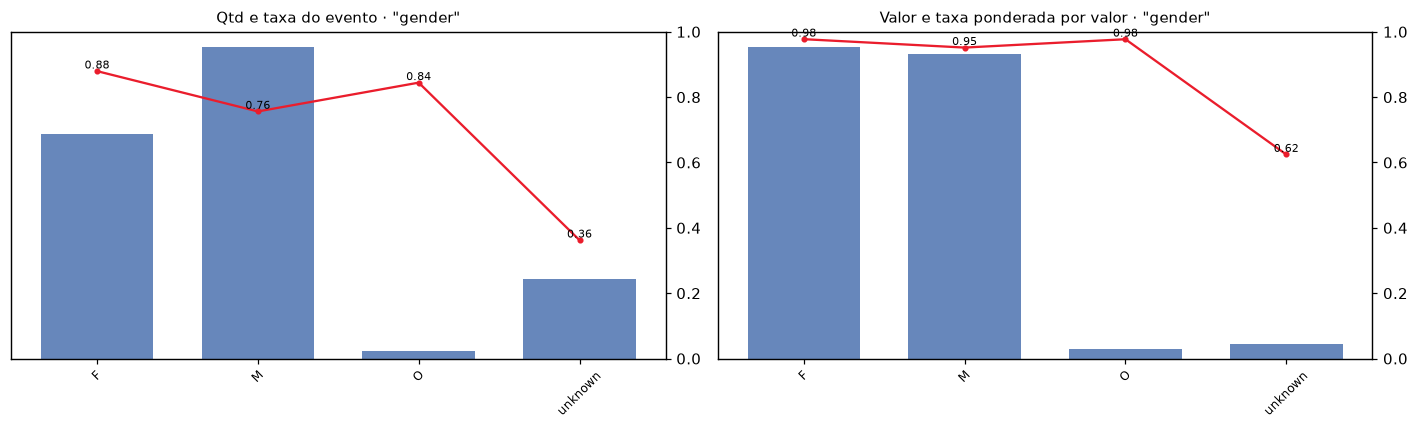

[incomplete_profile] amplitude da taxa: 0.446


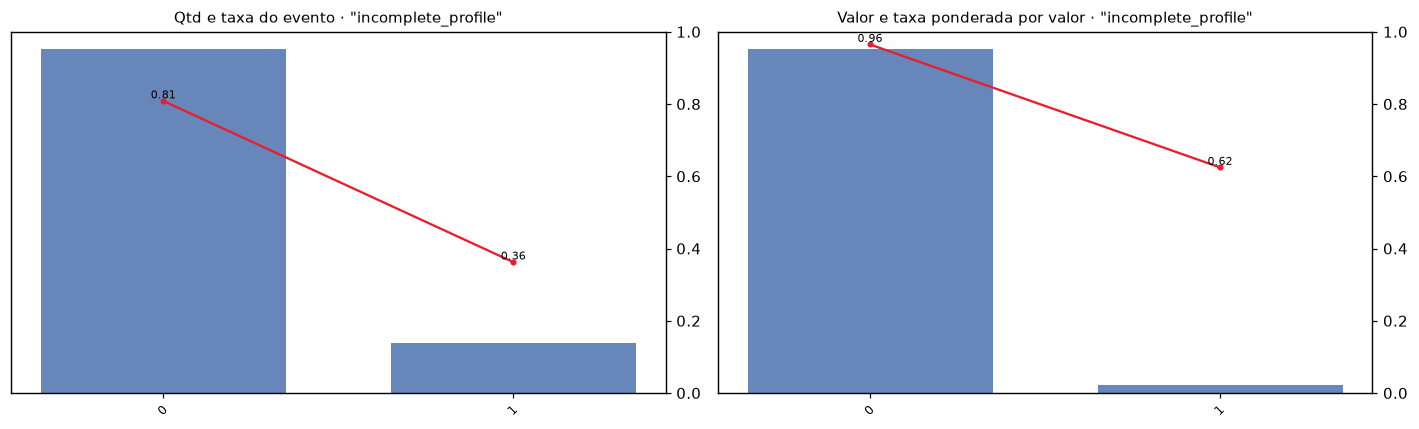

In [29]:
_ = plot_bad_cbk(cust, 'gender', 'completou_alguma', 'total_spend', teto=1.0)
_ = plot_bad_cbk(cust, 'incomplete_profile', 'completou_alguma', 'total_spend', teto=1.0)

**Leitura:** perfis incompletos convertem bem menos (menos histórico/engajamento). Diferenças por gênero existem, mas são secundárias frente ao comportamento.

### Idade e limite de crédito vs alvo (binning por quantis)

[age_q] amplitude da taxa: 0.480


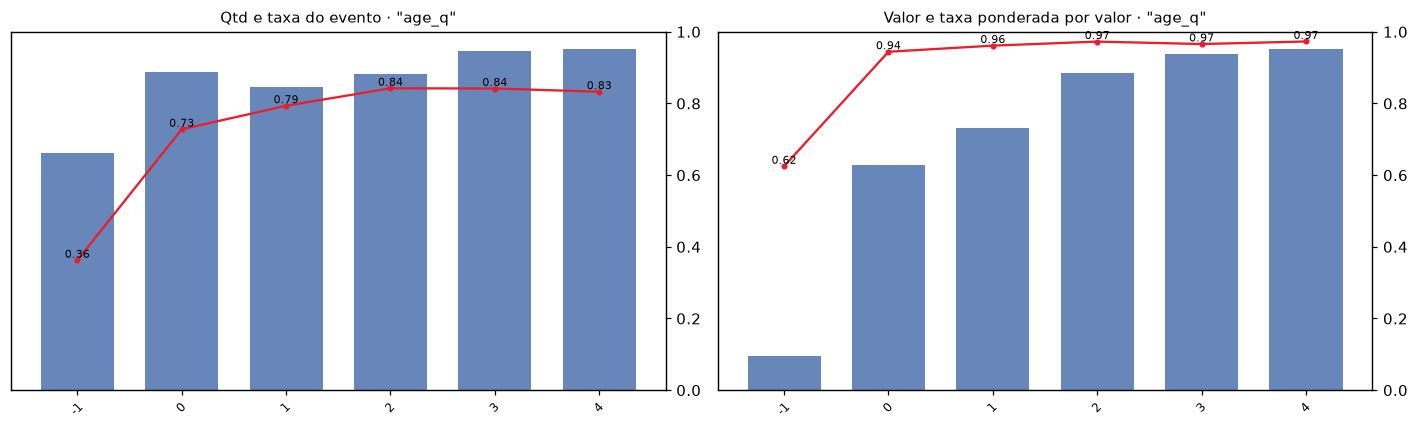

[lim_q] amplitude da taxa: 0.572


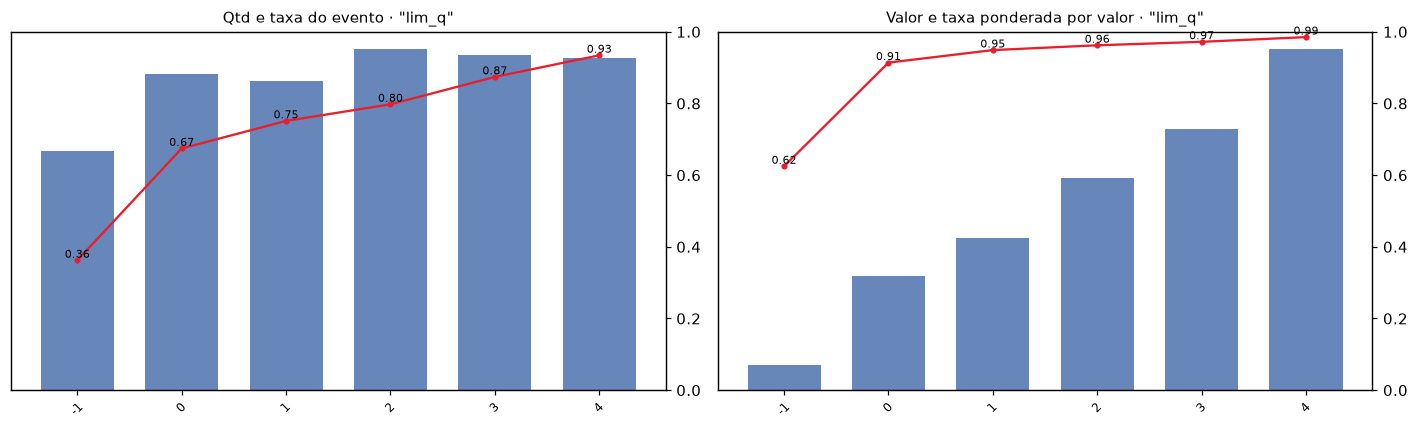

In [30]:
cust_age = quantiliza_com_missing(cust, 'age', 'age_q', 5)
_ = plot_bad_cbk(cust_age, 'age_q', 'completou_alguma', 'total_spend', teto=1.0)
cust_lim = quantiliza_com_missing(cust, 'credit_card_limit', 'lim_q', 5)
_ = plot_bad_cbk(cust_lim, 'lim_q', 'completou_alguma', 'total_spend', teto=1.0)

**Leitura:** idade e limite de crédito são **monotonicamente crescentes** com a taxa de conclusão — clientes mais velhos e de maior limite completam mais ofertas. (Bucket -1 = missing.)

### Idade da conta (`account_age`) vs alvo

[ac_q] amplitude da taxa: 0.340


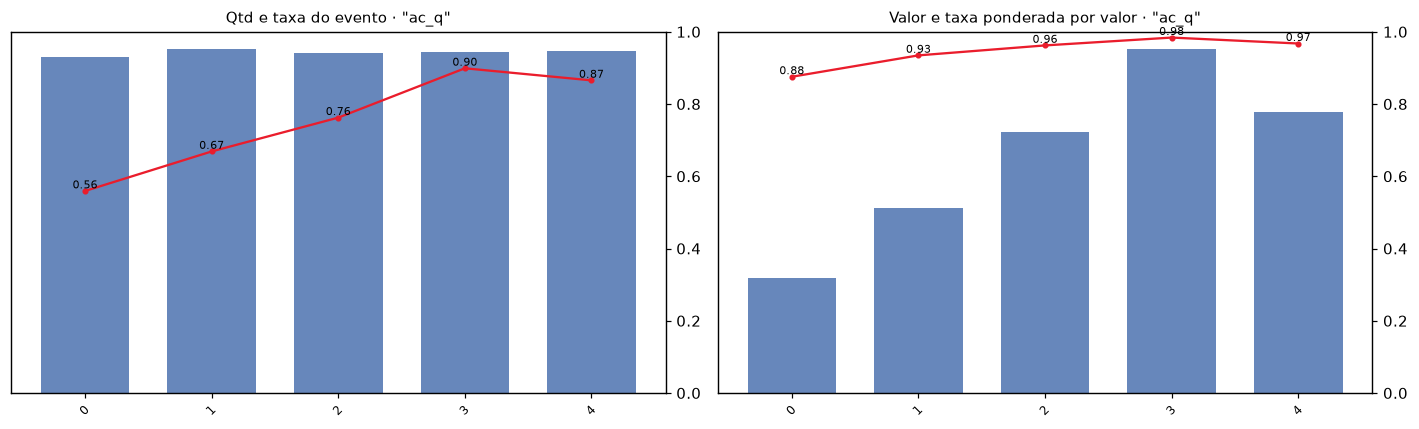

       min   max
ac_q            
0     0.00  0.47
1     0.48  0.81
2     0.82  1.42
3     1.43  2.39
4     2.40  4.99


In [31]:
cust_ac = quantiliza_com_missing(cust, 'account_age_years', 'ac_q', 5)
_ = plot_bad_cbk(cust_ac, 'ac_q', 'completou_alguma', 'total_spend', teto=1.0)
print(cust_ac.groupby('ac_q')['account_age_years'].agg(['min','max']).round(2).to_string())

**Leitura:** a idade da conta é um **forte sinal positivo**: a taxa de conclusão sobe de ~56% (contas novas, <0,5 ano) para ~90% (contas de 1,4–2,4 anos), com leve queda no grupo mais antigo. Clientes com **relacionamento mais consolidado** completam muito mais ofertas — boa feature de perfil.

### Comportamento (RFM) vs alvo

[sp_q] amplitude da taxa: 0.796


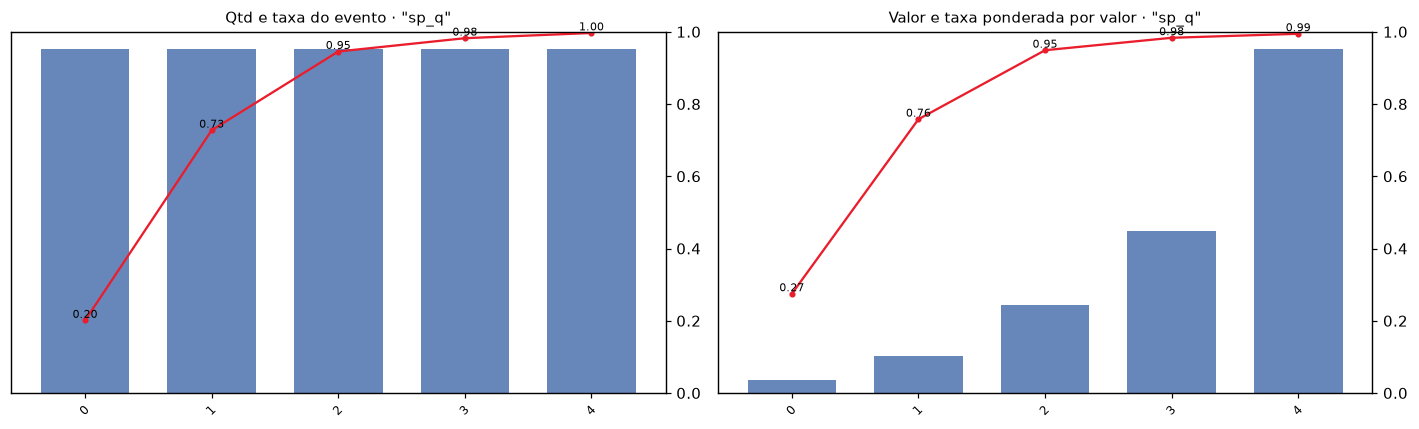

[tk_q] amplitude da taxa: 0.657


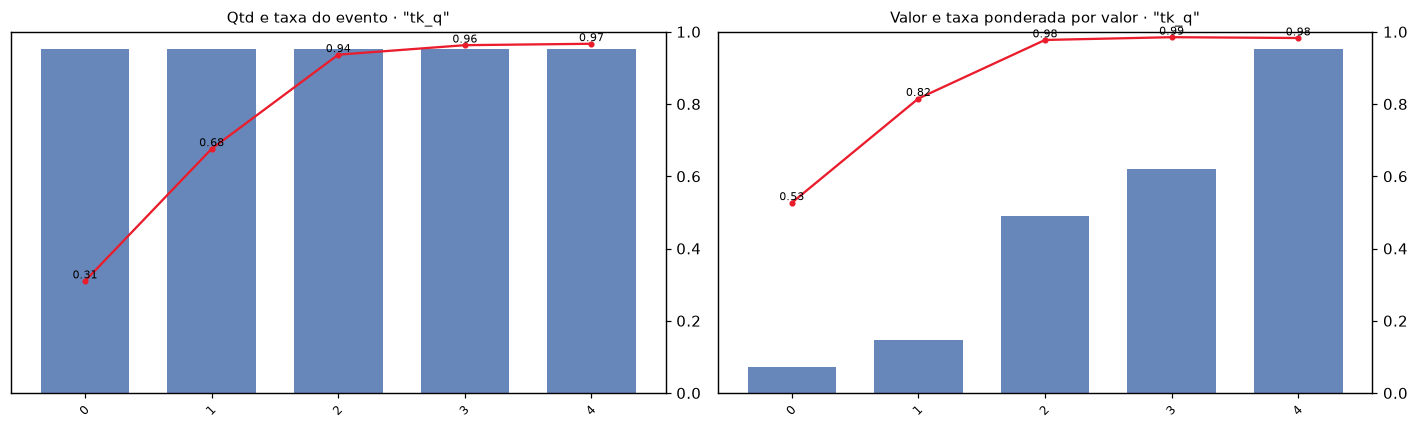

In [32]:
cust_sp = quantiliza_com_missing(cust[cust.total_spend>0], 'total_spend', 'sp_q', 5)
_ = plot_bad_cbk(cust_sp, 'sp_q', 'completou_alguma', 'total_spend', teto=1.0)
cust_tk = quantiliza_com_missing(cust[cust.avg_ticket>0], 'avg_ticket', 'tk_q', 5)
_ = plot_bad_cbk(cust_tk, 'tk_q', 'completou_alguma', 'total_spend', teto=1.0)

**Leitura:** gasto total e ticket médio discriminam fortemente a conclusão — clientes mais ativos completam mais ofertas. Ressalva importante: uma taxa de conclusão alta não implica que a oferta *causou* a compra (parte desses clientes já compraria de qualquer forma).

# Correlações entre variáveis numéricas (nível cliente)

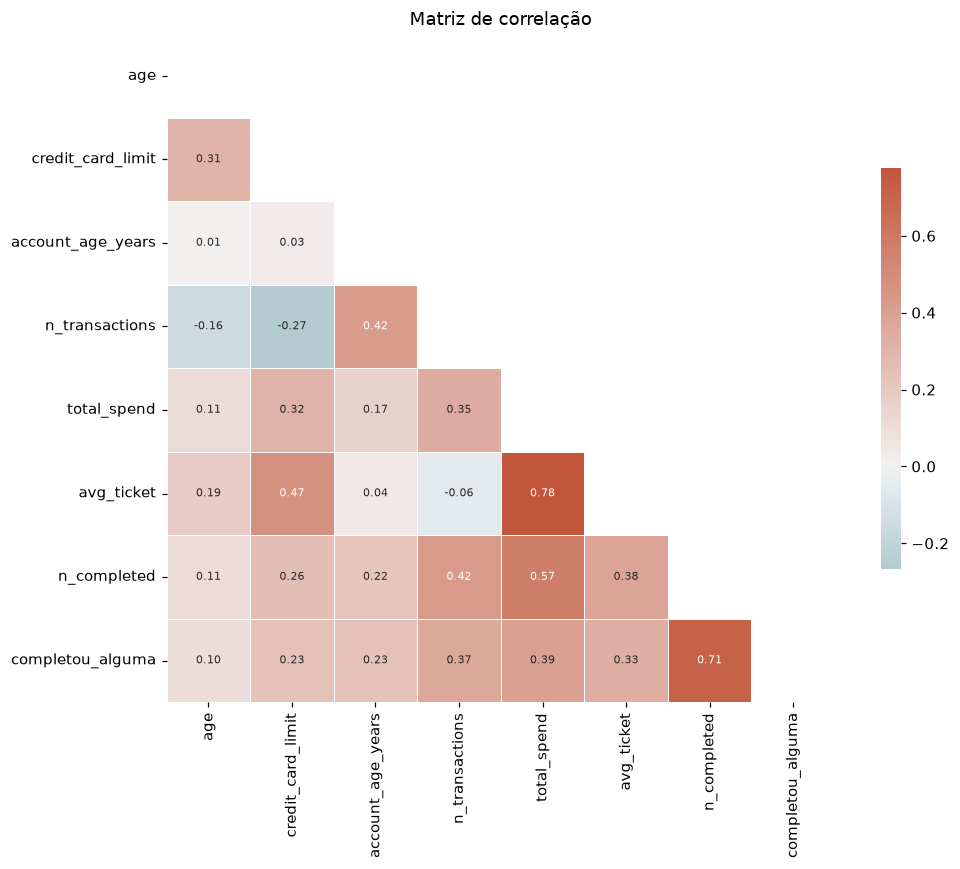

Variáveis com |correlação| >= 0.75 : ['avg_ticket']


In [33]:
num_cols = ['age','credit_card_limit','account_age_years','n_transactions',
            'total_spend','avg_ticket','n_completed','completou_alguma']
high = print_correlation_matrix(cust, num_cols, corr_max=0.75)

**Leitura:** as variáveis de volume/gasto são correlacionadas entre si (candidatas a redução na feature selection). Nenhuma variável de perfil sozinha domina o alvo — o sinal vem da combinação perfil + comportamento.

# Conclusões da EDA (dados brutos)
1. **Qualidade:** `age==118` = perfil incompleto (~12,8%) ≡ nulos de gênero/limite →
   flag + imputação no processing.
2. **Ofertas:** 4 BOGO, 4 discount, 2 informational; duração 3–10 dias define a
   **janela de atribuição** do processing; `informational` não tem "completar".
3. **Funil:** ~75% de visualização e ~44% de conclusão (agregado); há indícios de
   **conclusão sem visualização** (recompensa desperdiçada) → precisa ser quantificado
   com precisão via janela temporal no processing.
4. **Sinais preditivos:** idade, limite de crédito e RFM (gasto/ticket/transações)
   crescem com a conclusão → boas features; volume/gasto são correlacionados
   (candidatos a redução na feature selection).
5. **Timing:** envios de oferta são **em lote** em 6 dias (0,7,14,17,21,24), com
   cadência que **acelera** (de semanal para cada 3–4 dias); cada envio gera uma onda
   decrescente de visualização/conclusão — relevante para timing de campanha.

→ Próximo passo: `1_data_processing.ipynb` (atribuição por janela + dataset unificado).
